# Advanced Volatility Analysis: Drawdowns and GARCH Modeling

This notebook extends the exploratory analysis of US Economic Policy Uncertainty (EPU) and financial markets (S&P 500, Gold, Bitcoin) by implementing:
1. **Drawdown Analysis**: Measuring peak-to-trough declines.
2. **GARCH Modeling**: Estimating conditional volatility using Generalized Autoregressive Conditional Heteroskedasticity models.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Attempt to import arch, install if missing
try:
    from arch import arch_model
except ImportError:
    !pip install arch
    from arch import arch_model

import warnings
warnings.filterwarnings('ignore')

# Setup paths
DATA_PROCESSED = Path('../../data/processed')

# Plotting style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (15, 6)
plt.rcParams['figure.dpi'] = 100

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 927.7/927.7 kB 16.6 MB/s  0:00:00

[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


## 1. Load Data

In [2]:
df = pd.read_csv(DATA_PROCESSED / 'usepu_assets_daily_features.csv', parse_dates=['Date'])
df.sort_values('Date', inplace=True)
df.set_index('Date', inplace=True)
df.head()

,EPU,ΔEPU,EPU_MA30,EPU_Std30,SP500_Close,SP500_Open,SP500_High,SP500_Low,SP500_Return,SP500_Vol7d,...,Gold_Vol30d,Gold_Vol90d,BTC_Close,BTC_Open,BTC_High,BTC_Low,BTC_Return,BTC_Vol7d,BTC_Vol30d,BTC_Vol90d
Date,,,,,,,,,,,,,,,,,,,,,
2014-01-03,113.11,10.03,92.407333,34.711893,1831.4,1833.2,1838.2,1829.1,-0.000328,0.004576,...,0.012946,0.013518,884.3,856.9,888.2,839.4,NaN,NaN,NaN,NaN
2014-01-06,121.14,-23.77,96.903000,35.432950,1826.8,1832.3,1837.2,1823.7,-0.002515,0.004514,...,0.012768,0.013340,1012.7,1014.7,1093.4,964.7,-0.001973,NaN,NaN,NaN
2014-01-07,93.88,-27.26,97.600667,35.149982,1837.9,1828.7,1840.1,1828.7,0.006058,0.004790,...,0.012657,0.013351,879.9,1012.7,1044.0,879.8,-0.140567,NaN,NaN,NaN
2014-01-08,106.42,12.54,98.890667,34.723101,1837.5,1837.9,1840.0,1831.4,-0.000218,0.004790,...,0.012667,0.013350,938.8,879.9,966.9,858.9,0.064794,NaN,NaN,NaN
2014-01-09,60.31,-46.11,97.618667,35.430783,1838.1,1839.0,1843.2,1830.4,0.000326,0.004796,...,0.012680,0.013313,937.0,938.8,964.6,866.5,-0.001919,NaN,NaN,NaN


## 2. Drawdown Analysis

Drawdown is calculated as:
$$ Dd_t = \frac{P_t}{\max(P_{s \le t})} - 1 $$

It represents the cumulative loss from the historical peak.

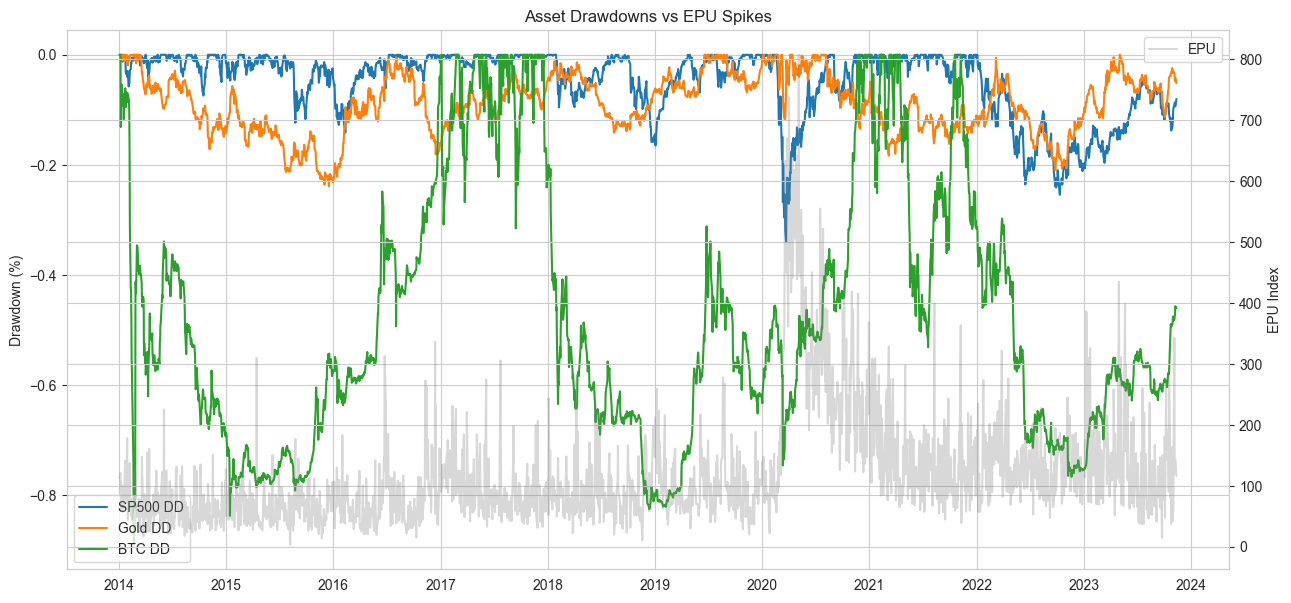

In [ ]:
def calculate_drawdown(series):
    cumulative_max = series.cummax()
    drawdown = (series / cumulative_max) - 1
    return drawdown

assets = ['SP500', 'Gold', 'BTC']
for asset in assets:
    df[f'{asset}_Drawdown'] = calculate_drawdown(df[f'{asset}_Close']) #TODO: Preguntar a Inés si es correcto con el cierre

# Plot Drawdowns
fig, ax1 = plt.subplots(figsize=(15, 7))

for asset in assets:
    ax1.plot(df.index, df[f'{asset}_Drawdown'], label=f'{asset} DD')

ax1.set_ylabel('Drawdown (%)')
ax1.set_title('Asset Drawdowns vs EPU Spikes')
ax1.legend(loc='lower left')

ax2 = ax1.twinx()
ax2.plot(df.index, df['EPU'], color='gray', alpha=0.3, label='EPU')
ax2.set_ylabel('EPU Index')
ax2.legend(loc='upper right')

plt.show()

## 3. GARCH(1,1) Volatility Modeling

We use GARCH(1,1) to estimate the conditional variance of returns.

--- GARCH(1,1) Results for SP500 ---
                     Constant Mean - GARCH Model Results                      
Dep. Variable:           SP500_Return   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -2859.33
Distribution:                  Normal   AIC:                           5726.66
Method:            Maximum Likelihood   BIC:                           5749.50
                                        No. Observations:                 2227
Date:                Mon, Feb 23 2026   Df Residuals:                     2226
Time:                        11:52:07   Df Model:                            1
                                 Mean Model                                 
                 coef    std err          t      P>|t|      95.0% Conf. Int.
----------------------------------------------------------------------------
mu             0.0669

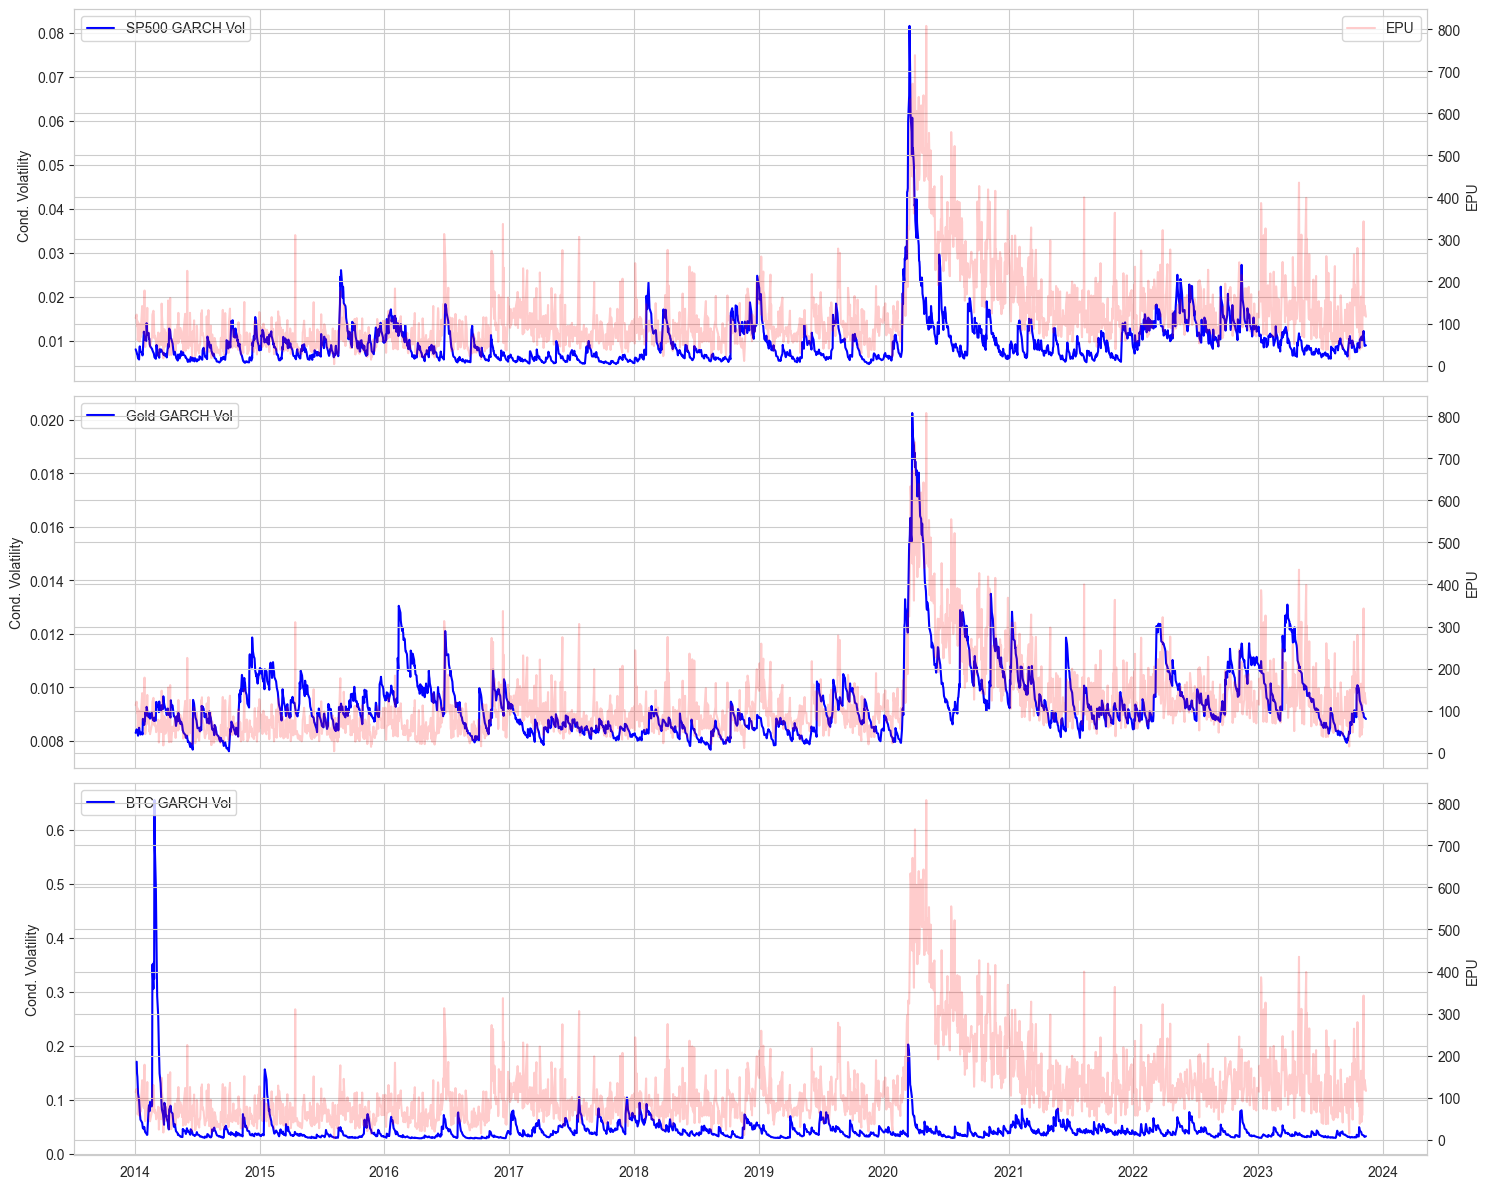

In [4]:
def fit_garch(returns, name):
    # Rescale returns to improve convergence
    rescaled_returns = returns * 100
    model = arch_model(rescaled_returns.dropna(), vol='Garch', p=1, q=1, dist='Normal')
    res = model.fit(disp='off')
    # Re-scale volatility back
    cond_vol = res.conditional_volatility / 100
    print(f"--- GARCH(1,1) Results for {name} ---")
    print(res.summary())
    return cond_vol

for asset in assets:
    df[f'{asset}_GARCH_Vol'] = fit_garch(df[f'{asset}_Return'], asset)

# Compare GARCH Volatility with EPU
fig, axes = plt.subplots(3, 1, figsize=(15, 12), sharex=True)

for i, asset in enumerate(assets):
    axes[i].plot(df.index, df[f'{asset}_GARCH_Vol'], label=f'{asset} GARCH Vol', color='blue')
    axes[i].set_ylabel('Cond. Volatility')
    axes[i].legend(loc='upper left')
    
    ax_twin = axes[i].twinx()
    ax_twin.plot(df.index, df['EPU'], color='red', alpha=0.2, label='EPU')
    ax_twin.set_ylabel('EPU')
    if i == 0: ax_twin.legend(loc='upper right')

plt.tight_layout()
plt.show()